# Feature Engineering and Clustering Experiments  
**TF-IDF, LDA Topic Vectors, and SBERT Embeddings**

**Feature engineering + clustering**

**Inputs:** `arxiv_clustering_cleaned_data_.csv` (pre-cleaned 150-word title+abstract records)  
**Outputs:** Feature matrices + cluster assignment artifacts saved under `outputs/`

> Reproducibility note: random seeds are fixed; splits are stratified by label.


## 1. Environment Setup and Imports


In [ ]:

# (Uncomment if required)
# !pip install -q pandas numpy scipy scikit-learn matplotlib nltk sentence-transformers umap-learn

import os
import re
import json
import math
import numpy as np
import pandas as pd

from dataclasses import dataclass
from typing import Dict, Tuple, List, Optional

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# INPUT PATH TO DATA HERE
INPUT_CSV = r"\Assignment-2-clustering\data\arxiv_clustering_cleaned_data_.csv"

OUT_DIR = "outputs"
OUT_FEATURES = os.path.join(OUT_DIR, "features")
OUT_ASSIGN = os.path.join(OUT_DIR, "cluster_assignments")
OUT_FIG = os.path.join(OUT_DIR, "figures")

for p in [OUT_DIR, OUT_FEATURES, OUT_ASSIGN, OUT_FIG]:
    os.makedirs(p, exist_ok=True)

print("Output directories ready:", OUT_DIR)


Output directories ready: outputs


## 2. Dataset Loading and Integrity Checks


In [6]:

df = pd.read_csv(INPUT_CSV)

print("Shape:", df.shape)
print("Columns:", list(df.columns))

# Expected minimal schema for this notebook
required_cols = ["text", "label"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Create a stable doc_id
df = df.reset_index(drop=True).copy()
df["doc_id"] = df.index.astype(int)

# Basic integrity checks
assert df["text"].isna().sum() == 0, "Missing text values found."
assert df["label"].isna().sum() == 0, "Missing label values found."

print("\nLabel distribution:")
display(df["label"].value_counts())

# Word-count sanity (expects about 150 words, but we tolerate small deviations)
df["wc"] = df["text"].astype(str).str.split().str.len()
print("\nWord-count summary:")
display(df["wc"].describe())

# Optional: flag unusually short/long records (should be rare)
short = (df["wc"] < 120).sum()
long = (df["wc"] > 180).sum()
print(f"\nRecords with wc < 120: {short} | wc > 180: {long}")


Shape: (1000, 9)
Columns: ['text', 'label', 'year', 'authors', 'title', 'abstract', 'title_word_count', 'abstract_word_count', 'total_word_count']

Label distribution:


label
Computer Vision     200
Cryptography        200
Machine Learning    200
NLP                 200
Robotics            200
Name: count, dtype: int64


Word-count summary:


count    1000.0
mean      150.0
std         0.0
min       150.0
25%       150.0
50%       150.0
75%       150.0
max       150.0
Name: wc, dtype: float64


Records with wc < 120: 0 | wc > 180: 0


In [ ]:

# --- Create stratified splits (train/val/test) for fair comparison across features ---

train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=RANDOM_SEED, stratify=df["label"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=RANDOM_SEED, stratify=temp_df["label"]
)

df["split"] = "unused"
df.loc[train_df.index, "split"] = "train"
df.loc[val_df.index, "split"]   = "val"
df.loc[test_df.index, "split"]  = "test"

print(df["split"].value_counts())
print("\nTrain label distribution:")
display(df[df["split"]=="train"]["label"].value_counts())


split
train    700
val      150
test     150
Name: count, dtype: int64

Train label distribution:


label
Computer Vision     140
Cryptography        140
Machine Learning    140
NLP                 140
Robotics            140
Name: count, dtype: int64

## 3. Text Normalization Pipeline (Feature-Independent)


Input `text` is already lowercased and cleaned, apply a light, deterministic normalization
so that TF-IDF, LDA, and SBERT consume identical text.


In [ ]:

def normalize_text(s: str) -> str:
    s = str(s)
    # Collapse whitespace, strip
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["text_norm"] = df["text"].map(normalize_text)

# Quick check
display(df[["doc_id", "label", "split", "text_norm"]].head())


,doc_id,label,split,text_norm
0,0,Computer Vision,train,noise aware learning web crawled image text da...
1,1,Computer Vision,val,bringing object life training free generation ...
2,2,Computer Vision,train,videorefer suite advancing spatial temporal ob...
3,3,Computer Vision,train,prototypical distillation debiased tuning blac...
4,4,Computer Vision,train,h nerf surface hyperspectral reconstruction st...


## 4. TF-IDF Feature Engineering


### 4.1 Motivation
TF-IDF is a strong lexical baseline for clustering scientific abstracts.


### 4.2 Vectorizer Configuration


In [9]:

tfidf_cfg = dict(
    lowercase=False,          # already normalized
    ngram_range=(1, 2),       # unigrams + bigrams help technical phrases
    min_df=5,                 # drop extremely rare terms
    max_df=0.90,              # drop ubiquitous terms
    max_features=50000        # cap for memory stability
)

tfidf = TfidfVectorizer(**tfidf_cfg)


### 4.3 Vectorization Execution


In [11]:

train_texts = df.loc[df["split"]=="train", "text_norm"].tolist()
val_texts   = df.loc[df["split"]=="val",   "text_norm"].tolist()
test_texts  = df.loc[df["split"]=="test",  "text_norm"].tolist()

X_tfidf_train = tfidf.fit_transform(train_texts)
X_tfidf_val   = tfidf.transform(val_texts)
X_tfidf_test  = tfidf.transform(test_texts)

print("TF-IDF shapes:", X_tfidf_train.shape, X_tfidf_val.shape, X_tfidf_test.shape)
print("Vocabulary size:", len(tfidf.vocabulary_))

# Persist features
from scipy import sparse
sparse.save_npz(os.path.join(OUT_FEATURES, "tfidf_train.npz"), X_tfidf_train)
sparse.save_npz(os.path.join(OUT_FEATURES, "tfidf_val.npz"),   X_tfidf_val)
sparse.save_npz(os.path.join(OUT_FEATURES, "tfidf_test.npz"),  X_tfidf_test)

with open(os.path.join(OUT_FEATURES, "tfidf_vocabulary.json"), "w", encoding="utf-8") as f:
    json.dump(tfidf.vocabulary_, f, default=int)

print("Saved TF-IDF feature matrices to:", OUT_FEATURES)


TF-IDF shapes: (700, 3383) (150, 3383) (150, 3383)
Vocabulary size: 3383
Saved TF-IDF feature matrices to: outputs\features


### 4.4 Diagnostic Outputs


In [12]:

# Show a small sample of high-IDF terms (rare but informative terms)
idf = tfidf.idf_
terms = np.array(tfidf.get_feature_names_out())
top_idf_idx = np.argsort(idf)[-20:][::-1]
diag = pd.DataFrame({"term": terms[top_idf_idx], "idf": idf[top_idf_idx]})
display(diag)


,term,idf
0,adaptability,5.760748
1,action execution,5.760748
2,action model,5.760748
3,abrupt,5.760748
4,add,5.760748
5,without training,5.760748
6,work introduce,5.760748
7,voice,5.760748
8,work leverage,5.760748
9,abstract,5.760748


## 5. LDA Topic Modeling


### 5.1 Conceptual Explanation
LDA yields interpretable topic vectors (doc to topic mixture) that can be clustered like any other feature space.


### 5.2 Topic Number Selection


In [13]:

# LDA uses a count-based representation
count_cfg = dict(
    lowercase=False,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.90,
    max_features=50000
)

count_vec = CountVectorizer(**count_cfg)

X_cnt_train = count_vec.fit_transform(train_texts)
X_cnt_val   = count_vec.transform(val_texts)
X_cnt_test  = count_vec.transform(test_texts)

print("Count matrix shapes:", X_cnt_train.shape, X_cnt_val.shape, X_cnt_test.shape)
print("Count vocabulary size:", len(count_vec.vocabulary_))


Count matrix shapes: (700, 3383) (150, 3383) (150, 3383)
Count vocabulary size: 3383


### 5.3 Model Training


In [ ]:

# Start with 5 topics (matches the number of human categories),
# and also produce 8 and 10 topics for robustness.
topic_counts = [5, 8, 10]

lda_models = {}
doc_topic = {}

for k in topic_counts:
    lda = LatentDirichletAllocation(
        n_components=k,
        random_state=RANDOM_SEED,
        learning_method="batch",
        max_iter=30,
        evaluate_every=-1,
    )
    lda.fit(X_cnt_train)
    lda_models[k] = lda

    # doc-topic distributions
    dt_train = lda.transform(X_cnt_train)
    dt_val   = lda.transform(X_cnt_val)
    dt_test  = lda.transform(X_cnt_test)

    doc_topic[k] = dict(train=dt_train, val=dt_val, test=dt_test)

    # Save doc-topic matrices
    np.save(os.path.join(OUT_FEATURES, f"lda_doc_topic_train_k{k}.npy"), dt_train)
    np.save(os.path.join(OUT_FEATURES, f"lda_doc_topic_val_k{k}.npy"),   dt_val)
    np.save(os.path.join(OUT_FEATURES, f"lda_doc_topic_test_k{k}.npy"),  dt_test)

print("Saved LDA doc-topic matrices for k in", topic_counts)


Saved LDA doc-topic matrices for k in [5, 8, 10]


### 5.4 Topic Interpretation


In [15]:

def top_words_per_topic(lda_model, feature_names, top_n=10):
    topics = []
    for topic_idx, topic in enumerate(lda_model.components_):
        top_idx = topic.argsort()[-top_n:][::-1]
        topics.append((topic_idx, [feature_names[i] for i in top_idx]))
    return topics

feature_names = np.array(count_vec.get_feature_names_out())

for k, lda in lda_models.items():
    print(f"\nTop words per topic (k={k}):")
    topics = top_words_per_topic(lda, feature_names, top_n=10)
    for topic_idx, words in topics:
        print(f"  Topic {topic_idx:02d}: {', '.join(words)}")



Top words per topic (k=5):
  Topic 00: model, language, task, video, training, fine, visual, language model, reasoning, benchmark
  Topic 01: model, language, llm, based, language model, large, human, study, ai, large language
  Topic 02: model, image, method, data, feature, learning, based, network, representation, training
  Topic 03: learning, robot, policy, agent, real, environment, multi, based, world, model
  Topic 04: learning, data, attack, based, network, system, privacy, model, security, detection

Top words per topic (k=8):
  Topic 00: model, video, language, visual, task, vision, image, training, data, text
  Topic 01: model, time, based, transformer, framework, attention, ai, image, series, multi
  Topic 02: model, method, feature, representation, data, training, object, image, learning, token
  Topic 03: learning, agent, policy, robot, rl, reinforcement, environment, real, multi, reinforcement learning
  Topic 04: attack, learning, data, network, based, privacy, adversar

### 5.5 Export Features


In [ ]:

# For clustering, use doc-topic matrix as dense feature vectors.
# Export CSV for k=5 (the canonical choice), and keep others as .npy.

k_can = 5
dt_all = np.vstack([
    doc_topic[k_can]["train"],
    doc_topic[k_can]["val"],
    doc_topic[k_can]["test"]
])

# Recover row order corresponding to concatenation
df_order = pd.concat([
    df[df["split"]=="train"],
    df[df["split"]=="val"],
    df[df["split"]=="test"]
], axis=0).copy()

assert len(df_order) == dt_all.shape[0]

dt_cols = [f"topic_{i}" for i in range(dt_all.shape[1])]
lda_feat_df = pd.DataFrame(dt_all, columns=dt_cols)
lda_feat_df.insert(0, "doc_id", df_order["doc_id"].values)

lda_csv = os.path.join(OUT_FEATURES, "lda_topic_vectors_k5.csv")
lda_feat_df.to_csv(lda_csv, index=False)
print("Saved:", lda_csv)


Saved: outputs\features\lda_topic_vectors_k5.csv


## 6. SBERT Embedding Generation


### 6.1 Motivation
SBERT embeddings often cluster better semantically than BoW/TF-IDF, but with reduced interpretability.


### 6.2 Model Choice
A compact model is recommended for speed (here: `all-MiniLM-L6-v2`).


In [ ]:

# If sentence-transformers is unavailable, install it in your environment.
try:
    from sentence_transformers import SentenceTransformer
except Exception as e:
    raise ImportError(
        "sentence-transformers not available. Install via `pip install sentence-transformers`."
    ) from e

SBERT_MODEL_NAME = "all-MiniLM-L6-v2"
sbert = SentenceTransformer(SBERT_MODEL_NAME)

print("Loaded SBERT:", SBERT_MODEL_NAME)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded SBERT: all-MiniLM-L6-v2


### 6.3 Embedding Computation


In [18]:

# Encode in split blocks to keep memory predictable.
def encode_texts(model, texts, batch_size=64):
    emb = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True,  # cosine similarity becomes dot product
    )
    return np.asarray(emb, dtype=np.float32)

E_train = encode_texts(sbert, train_texts, batch_size=64)
E_val   = encode_texts(sbert, val_texts,   batch_size=64)
E_test  = encode_texts(sbert, test_texts,  batch_size=64)

print("SBERT shapes:", E_train.shape, E_val.shape, E_test.shape)

np.save(os.path.join(OUT_FEATURES, "sbert_train.npy"), E_train)
np.save(os.path.join(OUT_FEATURES, "sbert_val.npy"),   E_val)
np.save(os.path.join(OUT_FEATURES, "sbert_test.npy"),  E_test)

with open(os.path.join(OUT_FEATURES, "sbert_model.json"), "w", encoding="utf-8") as f:
    json.dump({"model": SBERT_MODEL_NAME, "normalized": True}, f)

print("Saved SBERT embeddings to:", OUT_FEATURES)


Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

SBERT shapes: (700, 384) (150, 384) (150, 384)
Saved SBERT embeddings to: outputs\features


### 6.4 Embedding Diagnostics


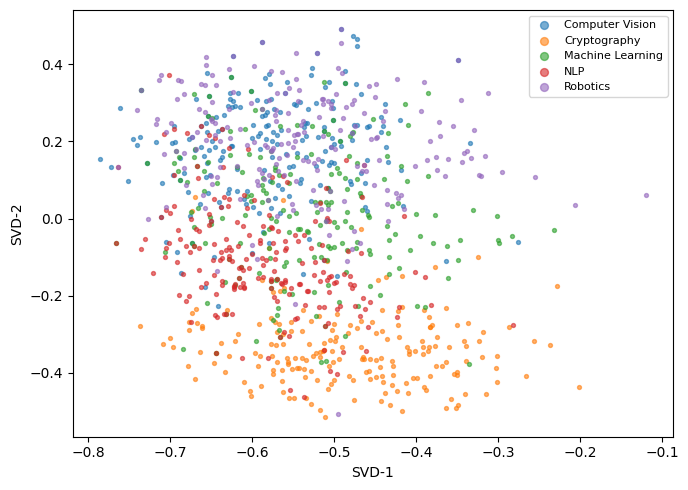

In [19]:

# Quick 2D diagnostic via TruncatedSVD (PCA-like for large matrices)
svd2 = TruncatedSVD(n_components=2, random_state=RANDOM_SEED)
E2 = svd2.fit_transform(np.vstack([E_train, E_val, E_test]))

df_order = pd.concat([
    df[df["split"]=="train"],
    df[df["split"]=="val"],
    df[df["split"]=="test"]
], axis=0).copy()

plt.figure(figsize=(7, 5))
for lab in sorted(df_order["label"].unique()):
    m = (df_order["label"] == lab).values
    plt.scatter(E2[m, 0], E2[m, 1], s=8, alpha=0.6, label=lab)
plt.xlabel("SVD-1")
plt.ylabel("SVD-2")
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, "sbert_svd2_scatter_by_label.png"), dpi=200)
plt.show()


## 7. Clustering Pipeline (Common Framework)


We run the same clustering algorithms across feature spaces, exporting a standardized assignment file for each run.
Cluster *evaluation* (kappa, silhouette, coherence) is handled by next; this notebook focuses on generating
clean, reproducible cluster assignments and associated artifacts.


In [20]:

@dataclass
class RunSpec:
    feature_type: str
    method: str
    variant: str  # linkage / covariance etc.
    k: int

def export_assignments(df_block: pd.DataFrame, cluster_ids: np.ndarray, spec: RunSpec, out_path: str):
    out = df_block[["doc_id", "label", "split"]].copy()
    out = out.rename(columns={"label": "true_label"})
    out["feature_type"] = spec.feature_type
    out["clustering_method"] = spec.method
    out["variant"] = spec.variant
    out["k"] = spec.k
    out["cluster_id"] = cluster_ids.astype(int)
    out.to_csv(out_path, index=False)
    return out_path

def concat_splits(train_arr, val_arr, test_arr):
    return np.vstack([train_arr, val_arr, test_arr])

df_all_ordered = pd.concat([
    df[df["split"]=="train"],
    df[df["split"]=="val"],
    df[df["split"]=="test"]
], axis=0).copy().reset_index(drop=True)

print("Ordered rows:", df_all_ordered.shape)


Ordered rows: (1000, 13)


## 8. K-Means Clustering


### 8.1 Configuration


In [21]:

K_CLUSTERS = 5

kmeans_cfg = dict(
    n_clusters=K_CLUSTERS,
    n_init=20,
    random_state=RANDOM_SEED
)


### 8.2 Execution Across Feature Types


In [ ]:

from scipy import sparse

# Load TF-IDF from disk to ensure use of persisted artifacts
X_tfidf_train = sparse.load_npz(os.path.join(OUT_FEATURES, "tfidf_train.npz"))
X_tfidf_val   = sparse.load_npz(os.path.join(OUT_FEATURES, "tfidf_val.npz"))
X_tfidf_test  = sparse.load_npz(os.path.join(OUT_FEATURES, "tfidf_test.npz"))

X_tfidf_all = sparse.vstack([X_tfidf_train, X_tfidf_val, X_tfidf_test])

# LDA (k=5 topics) already as dense
dt_train = np.load(os.path.join(OUT_FEATURES, "lda_doc_topic_train_k5.npy"))
dt_val   = np.load(os.path.join(OUT_FEATURES, "lda_doc_topic_val_k5.npy"))
dt_test  = np.load(os.path.join(OUT_FEATURES, "lda_doc_topic_test_k5.npy"))
X_lda_all = concat_splits(dt_train, dt_val, dt_test)

# SBERT embeddings
E_train = np.load(os.path.join(OUT_FEATURES, "sbert_train.npy"))
E_val   = np.load(os.path.join(OUT_FEATURES, "sbert_val.npy"))
E_test  = np.load(os.path.join(OUT_FEATURES, "sbert_test.npy"))
X_sbert_all = concat_splits(E_train, E_val, E_test)

runs = []

# KMeans on TF-IDF (sparse)
km = KMeans(**kmeans_cfg)
tfidf_labels = km.fit_predict(X_tfidf_all)
path = os.path.join(OUT_ASSIGN, "kmeans_tfidf.csv")
runs.append(export_assignments(df_all_ordered, tfidf_labels, RunSpec("tfidf","kmeans","default",K_CLUSTERS), path))

# KMeans on LDA topic vectors (dense)
km = KMeans(**kmeans_cfg)
lda_labels = km.fit_predict(X_lda_all)
path = os.path.join(OUT_ASSIGN, "kmeans_lda_k5.csv")
runs.append(export_assignments(df_all_ordered, lda_labels, RunSpec("lda_topics_k5","kmeans","default",K_CLUSTERS), path))

# KMeans on SBERT (dense)
km = KMeans(**kmeans_cfg)
sbert_labels = km.fit_predict(X_sbert_all)
path = os.path.join(OUT_ASSIGN, "kmeans_sbert.csv")
runs.append(export_assignments(df_all_ordered, sbert_labels, RunSpec("sbert","kmeans","default",K_CLUSTERS), path))

print("Saved:", *runs, sep="\n - ")


Saved:
 - outputs\cluster_assignments\kmeans_tfidf.csv
 - outputs\cluster_assignments\kmeans_lda_k5.csv
 - outputs\cluster_assignments\kmeans_sbert.csv


### 8.3 Preliminary Diagnostics


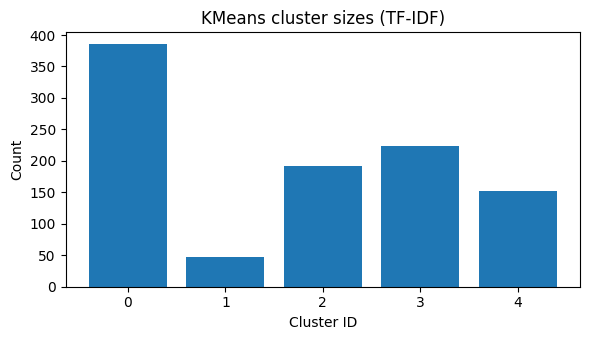

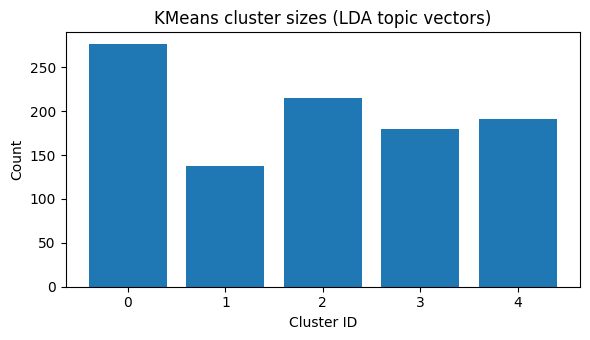

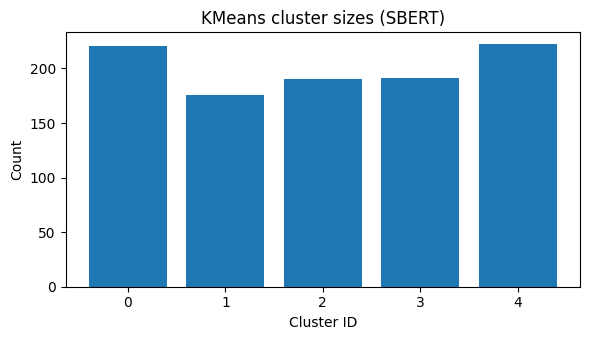

In [23]:

def plot_cluster_sizes(cluster_ids, title, outname):
    counts = pd.Series(cluster_ids).value_counts().sort_index()
    plt.figure(figsize=(6, 3.5))
    plt.bar(counts.index.astype(str), counts.values)
    plt.xlabel("Cluster ID")
    plt.ylabel("Count")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_FIG, outname), dpi=200)
    plt.show()

plot_cluster_sizes(tfidf_labels, "KMeans cluster sizes (TF-IDF)", "kmeans_tfidf_cluster_sizes.png")
plot_cluster_sizes(lda_labels,   "KMeans cluster sizes (LDA topic vectors)", "kmeans_lda_cluster_sizes.png")
plot_cluster_sizes(sbert_labels, "KMeans cluster sizes (SBERT)", "kmeans_sbert_cluster_sizes.png")


## 9. Gaussian Mixture (EM) Clustering


### 9.1 Motivation
GMM provides soft assignments (probabilities), often reflecting overlap between adjacent categories.


### 9.2 Model Settings


In [24]:

# GMM expects dense input. For TF-IDF, we reduce dimensionality with TruncatedSVD.
SVD_DIM = 100

svd = TruncatedSVD(n_components=SVD_DIM, random_state=RANDOM_SEED)
X_tfidf_svd = svd.fit_transform(X_tfidf_all)

print("TF-IDF reduced shape:", X_tfidf_svd.shape)


TF-IDF reduced shape: (1000, 100)


### 9.3 Execution


In [25]:

gmm_cfg = dict(
    n_components=K_CLUSTERS,
    random_state=RANDOM_SEED,
    covariance_type="diag",
    max_iter=300
)

runs = []

# GMM on TF-IDF (reduced)
gmm = GaussianMixture(**gmm_cfg)
gmm_tfidf = gmm.fit_predict(X_tfidf_svd)
path = os.path.join(OUT_ASSIGN, "gmm_tfidf_svd100_diag.csv")
runs.append(export_assignments(df_all_ordered, gmm_tfidf, RunSpec("tfidf_svd100","gmm","diag",K_CLUSTERS), path))

# GMM on LDA vectors
gmm = GaussianMixture(**gmm_cfg)
gmm_lda = gmm.fit_predict(X_lda_all)
path = os.path.join(OUT_ASSIGN, "gmm_lda_k5_diag.csv")
runs.append(export_assignments(df_all_ordered, gmm_lda, RunSpec("lda_topics_k5","gmm","diag",K_CLUSTERS), path))

# GMM on SBERT
gmm = GaussianMixture(**gmm_cfg)
gmm_sbert = gmm.fit_predict(X_sbert_all)
path = os.path.join(OUT_ASSIGN, "gmm_sbert_diag.csv")
runs.append(export_assignments(df_all_ordered, gmm_sbert, RunSpec("sbert","gmm","diag",K_CLUSTERS), path))

print("Saved:", *runs, sep="\n - ")


Saved:
 - outputs\cluster_assignments\gmm_tfidf_svd100_diag.csv
 - outputs\cluster_assignments\gmm_lda_k5_diag.csv
 - outputs\cluster_assignments\gmm_sbert_diag.csv


## 10. Hierarchical Clustering


### 10.1 Motivation
Hierarchical clustering can reveal coarse-to-fine relationships (e.g., ML to NLP to CV overlap).


### 10.2 Linkage Strategies
Run (1) Ward linkage on reduced Euclidean space and (2) Average linkage with cosine metric where applicable.


### 10.3 Execution


In [26]:

runs = []

# TF-IDF: use SVD-reduced for Ward linkage (Euclidean)
ward = AgglomerativeClustering(n_clusters=K_CLUSTERS, linkage="ward")
h_tfidf_ward = ward.fit_predict(X_tfidf_svd)
path = os.path.join(OUT_ASSIGN, "hier_tfidf_svd100_ward.csv")
runs.append(export_assignments(df_all_ordered, h_tfidf_ward, RunSpec("tfidf_svd100","hierarchical","ward",K_CLUSTERS), path))

# TF-IDF: average linkage with cosine metric (on normalized dense low-dim space)
# To keep memory stable, reuse SVD space and L2 normalize
X_tfidf_svd_norm = normalize(X_tfidf_svd)
avg_cos = AgglomerativeClustering(n_clusters=K_CLUSTERS, linkage="average", metric="cosine")
h_tfidf_avg = avg_cos.fit_predict(X_tfidf_svd_norm)
path = os.path.join(OUT_ASSIGN, "hier_tfidf_svd100_avgcos.csv")
runs.append(export_assignments(df_all_ordered, h_tfidf_avg, RunSpec("tfidf_svd100","hierarchical","average_cosine",K_CLUSTERS), path))

# LDA: ward (Euclidean) works naturally on low-dimensional dense vectors
ward = AgglomerativeClustering(n_clusters=K_CLUSTERS, linkage="ward")
h_lda_ward = ward.fit_predict(X_lda_all)
path = os.path.join(OUT_ASSIGN, "hier_lda_k5_ward.csv")
runs.append(export_assignments(df_all_ordered, h_lda_ward, RunSpec("lda_topics_k5","hierarchical","ward",K_CLUSTERS), path))

# LDA: average cosine
avg_cos = AgglomerativeClustering(n_clusters=K_CLUSTERS, linkage="average", metric="cosine")
h_lda_avg = avg_cos.fit_predict(normalize(X_lda_all))
path = os.path.join(OUT_ASSIGN, "hier_lda_k5_avgcos.csv")
runs.append(export_assignments(df_all_ordered, h_lda_avg, RunSpec("lda_topics_k5","hierarchical","average_cosine",K_CLUSTERS), path))

# SBERT: average cosine is a natural default
avg_cos = AgglomerativeClustering(n_clusters=K_CLUSTERS, linkage="average", metric="cosine")
h_sbert_avg = avg_cos.fit_predict(X_sbert_all)  # embeddings already normalized
path = os.path.join(OUT_ASSIGN, "hier_sbert_avgcos.csv")
runs.append(export_assignments(df_all_ordered, h_sbert_avg, RunSpec("sbert","hierarchical","average_cosine",K_CLUSTERS), path))

# SBERT: ward on euclidean (works, but less principled for cosine-optimized embeddings)
ward = AgglomerativeClustering(n_clusters=K_CLUSTERS, linkage="ward")
h_sbert_ward = ward.fit_predict(X_sbert_all)
path = os.path.join(OUT_ASSIGN, "hier_sbert_ward.csv")
runs.append(export_assignments(df_all_ordered, h_sbert_ward, RunSpec("sbert","hierarchical","ward",K_CLUSTERS), path))

print("Saved:", *runs, sep="\n - ")


Saved:
 - outputs\cluster_assignments\hier_tfidf_svd100_ward.csv
 - outputs\cluster_assignments\hier_tfidf_svd100_avgcos.csv
 - outputs\cluster_assignments\hier_lda_k5_ward.csv
 - outputs\cluster_assignments\hier_lda_k5_avgcos.csv
 - outputs\cluster_assignments\hier_sbert_avgcos.csv
 - outputs\cluster_assignments\hier_sbert_ward.csv


## 11. Consolidated Artifact Export


In [ ]:

# Merge all assignment CSVs into one master table for next phase
assign_files = [os.path.join(OUT_ASSIGN, f) for f in os.listdir(OUT_ASSIGN) if f.endswith(".csv")]
assign_files = sorted(assign_files)

frames = [pd.read_csv(p) for p in assign_files]
master = pd.concat(frames, axis=0, ignore_index=True)

master_path = os.path.join(OUT_ASSIGN, "MASTER_cluster_assignments.csv")
master.to_csv(master_path, index=False)

print("Wrote master assignments:", master_path)
print("Rows:", master.shape[0])
display(master.head())


Wrote master assignments: outputs\cluster_assignments\MASTER_cluster_assignments.csv
Rows: 12000


,doc_id,true_label,split,feature_type,clustering_method,variant,k,cluster_id
0,0,Computer Vision,train,lda_topics_k5,gmm,diag,5,3
1,2,Computer Vision,train,lda_topics_k5,gmm,diag,5,3
2,3,Computer Vision,train,lda_topics_k5,gmm,diag,5,3
3,4,Computer Vision,train,lda_topics_k5,gmm,diag,5,2
4,5,Computer Vision,train,lda_topics_k5,gmm,diag,5,3


## 12. Verification and Validation Section


In [ ]:

# Basic verification checks

# 1) Expected splits
assert set(df["split"].unique()) == {"train","val","test"}, "Unexpected split values."

# 2) Expected number of clusters produced in each run
bad = []
for p in assign_files:
    d = pd.read_csv(p)
    k = d["cluster_id"].nunique()
    if k != K_CLUSTERS:
        bad.append((os.path.basename(p), k))

if bad:
    print("WARNING: Some runs did not produce K clusters:")
    for name, k in bad:
        print(" -", name, "clusters:", k)
else:
    print("All runs produced exactly", K_CLUSTERS, "clusters.")

# 3) No missing cluster labels
assert master["cluster_id"].isna().sum() == 0, "Missing cluster ids in master."

print("Verification complete.")


All runs produced exactly 5 clusters.
Verification complete.


## 14. Handoff Notes to Zineb (DELETE BEFORE SUBMISSION)


**Primary artifact for evaluation:** `outputs/cluster_assignments/MASTER_cluster_assignments.csv`  
This contains one row per document per run, with columns:

- `doc_id`, `true_label`, `split`
- `feature_type`
- `clustering_method`, `variant`, `k`
- `cluster_id`

**Feature files (for potential re-use):**
- TF-IDF: `outputs/features/tfidf_*.npz` + `tfidf_vocabulary.json`
- LDA: `outputs/features/lda_doc_topic_*_k5.npy` (and k=8,10 candidates)
- SBERT: `outputs/features/sbert_*.npy` + `sbert_model.json`
